# Elevation

Cruza `data/spatial/vector/streets/processed/lion_metrics.gpkg` con `data/spatial/raster/nyc_dem/nyc_dem_1m.tif` y calcula por calle: `min`, `max`, `mean`, `sd`, `start`, `end` y `slope`.

Se usan los vertices existentes de cada geometria. Si `elevation_processed=True` ya existe en la salida, el notebook la reutiliza y no recalcula. El `dem_slope` se guarda como valor absoluto.


In [1]:
import json
import os
import subprocess
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import shapely
from PIL import Image
from pyproj import Transformer

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import matplotlib.pyplot as plt

Image.MAX_IMAGE_PIXELS = None
plt.style.use('seaborn-v0_8-whitegrid')

def find_project_root(start: Path | None = None) -> Path:
    """Return the repository root that contains `data/` and `notebooks/`."""
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('No se encontro la raiz del proyecto.')

ROOT = find_project_root()
STREETS_PATH = ROOT / 'data/spatial/vector/streets/processed/lion_metrics.gpkg'
DEM_PATH = ROOT / 'data/spatial/raster/nyc_dem/nyc_dem_1m.tif'
BOUNDARY_PATH = ROOT / 'data/spatial/vector/nyc_borough_boundary/nybb.geojson'
OUTPUT_PATH = ROOT / 'data/spatial/vector/streets/processed/lion_metrics_elevation.gpkg'
TARGET_CRS = 2263
DEM_CRS = 4326
BATCH_SIZE = 10000
REQUIRED_ELEVATION_COLUMNS = {
    'dem_min', 'dem_max', 'dem_mean', 'dem_sd',
    'dem_start', 'dem_end', 'dem_slope',
    'dem_vertex_n', 'elevation_processed',
}


In [2]:
def load_dem_metadata(path: Path) -> dict:
    """Read geotransform and nodata from GDAL JSON."""
    payload = json.loads(subprocess.run(
        ['gdalinfo', '-json', str(path)],
        capture_output=True,
        text=True,
        check=True,
    ).stdout)
    return {
        'transform': payload['geoTransform'],
        'width': int(payload['size'][0]),
        'height': int(payload['size'][1]),
        'nodata': payload['bands'][0].get('noDataValue'),
    }

def world_to_pixel(xs: np.ndarray, ys: np.ndarray, transform: list[float]) -> tuple[np.ndarray, np.ndarray]:
    """Convert world coordinates to raster row/column indices."""
    x0, px, _, y0, _, py = transform
    cols = np.floor((xs - x0) / px).astype(np.int64)
    rows = np.floor((y0 - ys) / abs(py)).astype(np.int64)
    return rows, cols

def prepare_streets(frame: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Normalize the street frame and project it to the DEM CRS."""
    streets = frame.copy()
    streets['edge_id'] = pd.to_numeric(streets['edge_id'], errors='coerce').astype('int64')
    streets['length'] = pd.to_numeric(streets['length'], errors='coerce')
    if streets.crs is None or streets.crs.to_epsg() != TARGET_CRS:
        streets = streets.to_crs(TARGET_CRS)
    streets['length'] = streets['length'].fillna(streets.geometry.length)
    streets['length'] = streets['length'].where(streets['length'] > 0, streets.geometry.length)
    return streets

def row_stats(values: np.ndarray, length_ft: float) -> tuple[float, float, float, float, float, float, float, int]:
    """Summarize sampled elevations for one street."""
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0)
    elev_min = float(np.nanmin(finite))
    elev_max = float(np.nanmax(finite))
    elev_mean = float(np.nanmean(finite))
    elev_sd = float(np.nanstd(finite))
    elev_start = float(finite[0])
    elev_end = float(finite[-1])
    elev_slope = float(abs((elev_end - elev_start) / length_ft)) if length_ft and np.isfinite(length_ft) and length_ft > 0 else np.nan
    return (elev_min, elev_max, elev_mean, elev_sd, elev_start, elev_end, elev_slope, int(finite.size))

def sample_batch_vertices(batch: gpd.GeoDataFrame, dem_img: Image.Image, dem_meta: dict, transformer: Transformer) -> pd.DataFrame:
    """Sample DEM values on the existing street vertices for one batch."""
    geoms = batch.geometry.to_numpy()
    coords, geom_idx = shapely.get_coordinates(geoms, return_index=True)
    if coords.size == 0:
        return pd.DataFrame(columns=[
            'edge_id', 'dem_min', 'dem_max', 'dem_mean', 'dem_sd',
            'dem_start', 'dem_end', 'dem_slope', 'dem_vertex_n',
        ])
    lon, lat = transformer.transform(coords[:, 0], coords[:, 1])
    rows, cols = world_to_pixel(np.asarray(lon), np.asarray(lat), dem_meta["transform"])
    valid = (rows >= 0) & (rows < dem_meta["height"]) & (cols >= 0) & (cols < dem_meta["width"])
    samples = np.full(len(coords), np.nan, dtype=np.float32)
    if valid.any():
        for row in np.unique(rows[valid]):
            row_mask = valid & (rows == row)
            row_cols = cols[row_mask]
            min_col = int(row_cols.min())
            max_col = int(row_cols.max())
            row_values = np.asarray(
                dem_img.crop((min_col, int(row), max_col + 1, int(row) + 1)),
                dtype=np.float32,
            ).reshape(-1).copy()
            nodata = dem_meta["nodata"]
            if nodata is not None:
                row_values[row_values == nodata] = np.nan
            samples[row_mask] = row_values[row_cols - min_col]
    counts = np.bincount(geom_idx, minlength=len(batch))
    offsets = np.cumsum(counts) - counts
    edge_ids = batch["edge_id"].to_numpy()
    lengths = batch["length"].to_numpy(dtype=float, copy=True)
    if np.isnan(lengths).any():
        lengths = np.where(np.isnan(lengths), shapely.length(geoms), lengths)
    rows_out = []
    for i, edge_id in enumerate(edge_ids):
        count = int(counts[i])
        start = int(offsets[i])
        street_samples = samples[start:start + count]
        dem_min, dem_max, dem_mean, dem_sd, dem_start, dem_end, dem_slope, dem_vertex_n = row_stats(street_samples, float(lengths[i]))
        rows_out.append({
            'edge_id': int(edge_id),
            'dem_min': dem_min,
            'dem_max': dem_max,
            'dem_mean': dem_mean,
            'dem_sd': dem_sd,
            'dem_start': dem_start,
            'dem_end': dem_end,
            'dem_slope': dem_slope,
            'dem_vertex_n': dem_vertex_n,
        })
    return pd.DataFrame(rows_out)

def build_elevation_metrics(streets: gpd.GeoDataFrame, dem_img: Image.Image, dem_meta: dict) -> gpd.GeoDataFrame:
    """Compute elevation summaries for every street edge."""
    transformer = Transformer.from_crs(TARGET_CRS, DEM_CRS, always_xy=True)
    batches = []
    for start in range(0, len(streets), BATCH_SIZE):
        stop = min(start + BATCH_SIZE, len(streets))
        batch = streets.iloc[start:stop].copy()
        print(f'  - batch {start:,} to {stop:,}', flush=True)
        batches.append(sample_batch_vertices(batch, dem_img, dem_meta, transformer))
    stats = pd.concat(batches, ignore_index=True) if batches else pd.DataFrame(columns=[
        'edge_id', 'dem_min', 'dem_max', 'dem_mean', 'dem_sd',
        'dem_start', 'dem_end', 'dem_slope', 'dem_vertex_n',
    ])
    result = streets.merge(stats, on="edge_id", how="left")
    result['elevation_processed'] = True
    return result

def is_complete_output(frame: gpd.GeoDataFrame) -> bool:
    """Check whether the output already contains elevation summaries."""
    return (
        REQUIRED_ELEVATION_COLUMNS.issubset(frame.columns)
        and frame["elevation_processed"].fillna(False).all()
        and frame["dem_slope"].dropna().ge(0).all()
    )

def load_or_build_elevation() -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """Load a finished output or build it from the raw street layer."""
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_epsg() != TARGET_CRS:
        boundary = boundary.to_crs(TARGET_CRS)
    if OUTPUT_PATH.exists():
        candidate = gpd.read_file(OUTPUT_PATH)
        if is_complete_output(candidate):
            print(f'Reutilizando salida procesada: {OUTPUT_PATH}', flush=True)
            return candidate, boundary
        print('La salida existe, pero esta incompleta. Se reconstruye.', flush=True)
    streets = prepare_streets(gpd.read_file(STREETS_PATH))
    dem_meta = load_dem_metadata(DEM_PATH)
    with Image.open(DEM_PATH) as dem_img:
        result = build_elevation_metrics(streets, dem_img, dem_meta)
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    result.to_file(OUTPUT_PATH, driver='GPKG')
    print(f'Salida escrita en: {OUTPUT_PATH}', flush=True)
    return result, boundary


In [3]:
result, boundary = load_or_build_elevation()

print(f'Rows: {len(result):,}')
print('Columns added:', [c for c in ['dem_min', 'dem_max', 'dem_mean', 'dem_sd', 'dem_start', 'dem_end', 'dem_slope', 'dem_vertex_n', 'elevation_processed'] if c in result.columns])
result[["dem_min", "dem_max", "dem_mean", "dem_sd", "dem_slope"]].head()


La salida existe, pero esta incompleta. Se reconstruye.
  - batch 0 to 10,000
  - batch 10,000 to 20,000
  - batch 20,000 to 30,000
  - batch 30,000 to 40,000
  - batch 40,000 to 50,000
  - batch 50,000 to 60,000
  - batch 60,000 to 70,000
  - batch 70,000 to 80,000
  - batch 80,000 to 90,000
  - batch 90,000 to 100,000
  - batch 100,000 to 110,000
  - batch 110,000 to 120,000
  - batch 120,000 to 130,000
  - batch 130,000 to 140,000
  - batch 140,000 to 150,000
  - batch 150,000 to 160,000
  - batch 160,000 to 170,000
  - batch 170,000 to 180,000
  - batch 180,000 to 190,000
  - batch 190,000 to 196,904
Salida escrita en: /home/map10194/Documents/urban-flood-stress/data/spatial/vector/streets/processed/lion_metrics_elevation.gpkg
Rows: 196,904
Columns added: ['dem_min', 'dem_max', 'dem_mean', 'dem_sd', 'dem_start', 'dem_end', 'dem_slope', 'dem_vertex_n', 'elevation_processed']


,dem_min,dem_max,dem_mean,dem_sd,dem_slope
0,26.799988,29.049997,27.924992,1.125005,0.018640
1,40.610004,40.679996,40.645000,0.034996,0.000822
2,20.410011,23.159992,21.785002,1.374990,0.014591
3,20.410011,23.159992,21.785002,1.374990,0.014591
4,20.410011,23.159992,21.785002,1.374990,0.014591


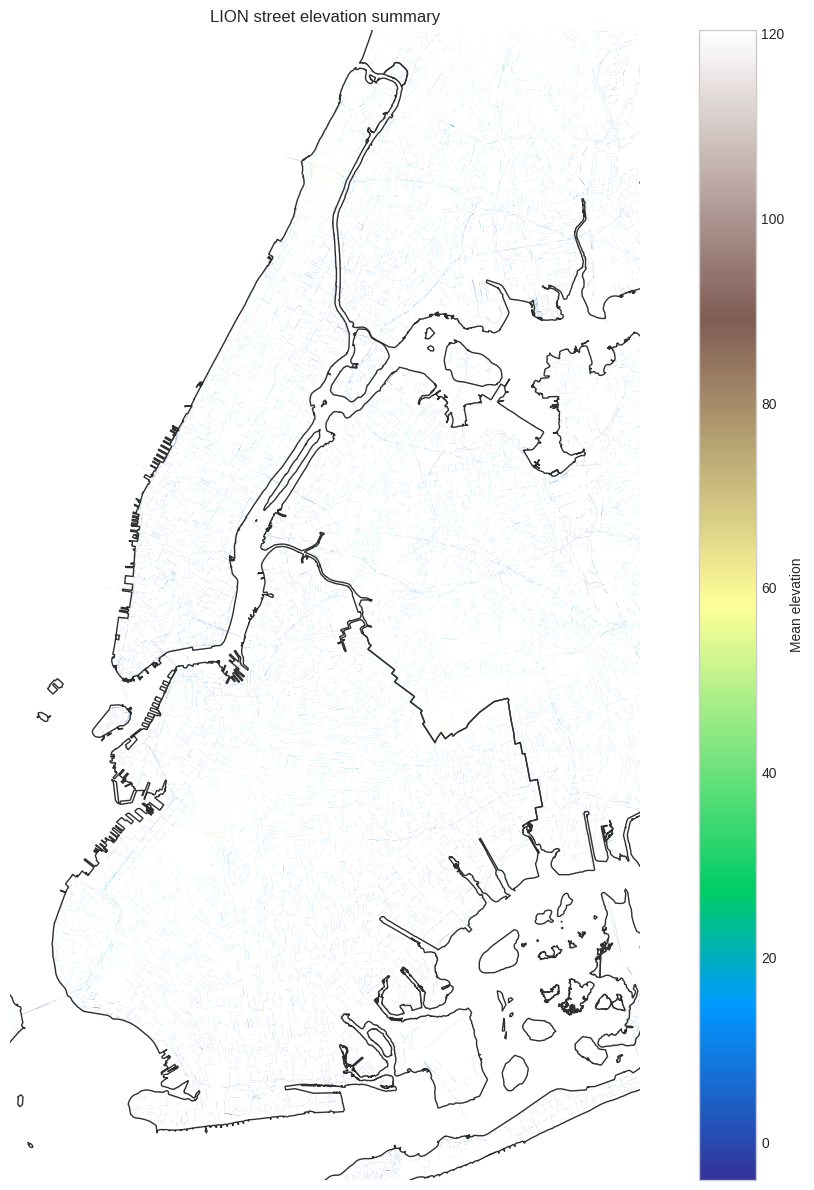

In [4]:
# Use a sample for readability if the layer is dense.
plot_frame = result if len(result) <= 50000 else result.sample(50000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 12))
boundary.boundary.plot(ax=ax, color="#2f2f2f", linewidth=1.0, zorder=1)
plot_frame.plot(
    ax=ax,
    column="dem_mean",
    cmap="terrain",
    linewidth=0.08,
    alpha=0.7,
    legend=True,
    legend_kwds={"label": "Mean elevation"},
    zorder=2,
)
xmin, ymin, xmax, ymax = boundary.total_bounds
pad_x = (xmax - xmin) * 0.03
pad_y = (ymax - ymin) * 0.03
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("LION street elevation summary")
plt.tight_layout()
plt.show()
